In [6]:
# ============================================================
# KLASIFIKASI BENTUK WAJAH PRIA - PIPELINE FINAL
# Kelas: ovale, rectangular, round, square
#
# Notebook ini menggabungkan semua yang TERBUKTI dari eksperimen v1-v13.
# Setiap keputusan di bawah punya bukti, bukan tebakan:
#
#   DIPAKAI:
#   + relabel dari nama file   : +1.89 poin  (ablasi v11, terkontrol)
#   + face cropping            : +5.14 poin  (ablasi v11, terkontrol)
#   + dedupe perceptual (dHash): mencegah +4.67 poin angka PALSU (v11)
#   + gabung train/test lalu split stratified ulang (v4)
#   + augmentasi ringan: flip + rotasi 0.06 + zoom 0.06 (v2)
#   + label smoothing 0.05 (v3 pakai 0.1 -> underfitting)
#   + dua tahap: kepala di atas embedding -> fine-tune 60 layer
#   + fine-tuning: +2.45 poin vs fitur beku, McNemar p=0.046 (v12)
#
#   TIDAK DIPAKAI (sudah diuji, tidak membantu):
#   - confident learning / pembersihan label: p=0.81, nol efek (v10)
#   - Test-Time Augmentation: 41.9% vs 43.5%, merugikan (v3)
#   - class_weight: distribusi train/test beda arah, mengganggu (v2)
#
#   PERANGKAP YANG DIHINDARI:
#   ! validation TIDAK BOLEH memakai test fold (bug v12, inflasi 2-4 poin)
#   ! callback harus objek BARU tiap fit() (bug v1, checkpoint tak tersimpan)
#   ! .cache() sebelum .batch(), atau langsung dari RAM (bug v5, 159 menit)
#   ! clear_session() tiap fold, model ke disk bukan ke list (bug v6)
#
# Hasil yang diharapkan: OOF 62-65%, top-2 ~84%, runtime ~10 menit.
# ============================================================

import os, shutil, pathlib, time, gc, json, csv
from collections import Counter
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    raise SystemExit("Butuh opencv: pip install opencv-python")

try:
    import psutil
    def mem_mb(): return psutil.Process().memory_info().rss / 1024**2
except ImportError:
    def mem_mb(): return float("nan")

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU') or "tidak ada (CPU)")

TensorFlow : 2.21.0
GPU        : tidak ada (CPU)


In [7]:
# ---------- KONFIGURASI ----------
RAW_DIR  = "dataset/men"          # dataset asli, TIDAK diubah
WORK_DIR = "build"                # semua hasil antara, aman dihapus
OUT_DIR  = "artifacts"            # model & metadata untuk inference

CLASSES = ["ovale", "rectangular", "round", "square"]
EXTS    = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')
NUM_CLASSES = len(CLASSES)

RES = 224
IMG_SIZE, IMG_SHAPE = (RES, RES), (RES, RES, 3)
CROP_MARGIN = 0.35                # perluas kotak wajah agar dahi & dagu masuk
HAMMING_THRESHOLD = 5             # jarak dHash <= ini dianggap gambar kembar

BATCH_SIZE = 64
N_FOLDS    = 5
VAL_FRAC   = 0.15                 # diambil dari porsi TRAINING, bukan test
SEED       = 42

EPOCHS_HEAD, PATIENCE_HEAD = 60, 10
EPOCHS_FT,   PATIENCE_FT   = 25, 5
FINE_TUNE_LAYERS = 60
LABEL_SMOOTHING  = 0.05

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
POOL_DIR = os.path.join(WORK_DIR, "pool")
CROP_DIR = os.path.join(WORK_DIR, "crop")

tf.keras.utils.set_random_seed(SEED)
print(f"Resolusi {RES}px | batch {BATCH_SIZE} | {N_FOLDS}-fold | seed {SEED}")

Resolusi 224px | batch 64 | 5-fold | seed 42


In [8]:
# ---------- 1. BANGUN POOL + RELABEL ----------
# Dua hal sekaligus:
#   (a) semua gambar disimpan ulang sebagai JPEG valid. Banyak file .jpg
#       di dataset ini sebenarnya berisi WEBP -> TensorFlow error saat baca.
#   (b) label diambil dari NAMA FILE kalau namanya menyebut kelas lain
#       daripada foldernya. Contoh: 'image square 158.jpg' yang duduk di
#       folder rectangular. Ada 59 kasus seperti ini.
#   Nama file diberi awalan TR__/TE__ untuk mencatat asal split.
t0 = time.time()
if os.path.exists(POOL_DIR):
    shutil.rmtree(POOL_DIR)
os.makedirs(POOL_DIR)

pool, n_relabel, n_skip = [], 0, 0
for split, tag in [("training_set", "TR"), ("testing_set", "TE")]:
    for folder in CLASSES:
        src = os.path.join(RAW_DIR, split, folder)
        if not os.path.isdir(src):
            continue
        for fn in sorted(os.listdir(src)):
            if fn.startswith(".") or not fn.lower().endswith(EXTS):
                continue
            low, label = fn.lower(), folder
            for c in CLASSES:
                if c in low and c != folder:
                    label = c; n_relabel += 1; break
            dst = os.path.join(POOL_DIR, f"{tag}__{folder}__{pathlib.Path(fn).stem}.jpg")
            try:
                with Image.open(os.path.join(src, fn)) as im:
                    im.convert("RGB").save(dst, "JPEG", quality=95)
            except Exception:
                n_skip += 1; continue
            pool.append((dst, CLASSES.index(label), tag))

pool_paths  = np.array([p for p, _, _ in pool])
pool_labels = np.array([l for _, l, _ in pool])
pool_origin = np.array([o for _, _, o in pool])

print(f"Pool: {len(pool)} gambar ({time.time()-t0:.1f}s)")
print(f"  label diperbaiki dari nama file : {n_relabel}")
print(f"  gagal dibaca / dilewati         : {n_skip}")
print(f"  asal training_set / testing_set : "
      f"{(pool_origin=='TR').sum()} / {(pool_origin=='TE').sum()}")

Pool: 1312 gambar (8.3s)
  label diperbaiki dari nama file : 59
  gagal dibaca / dilewati         : 0
  asal training_set / testing_set : 927 / 385


In [12]:
# ---------- 2. FACE CROPPING ----------
# Kontributor terbesar (+5.14 poin, ablasi v11). Bentuk wajah ditentukan
# geometri rahang & dahi; tanpa crop model ikut belajar rambut dan latar.
# Kotak wajah diperluas 35% agar dahi dan dagu tidak terpotong.
t0 = time.time()
if os.path.exists(CROP_DIR):
    shutil.rmtree(CROP_DIR)
os.makedirs(CROP_DIR)

CASCADE = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def crop_face_bgr(img_bgr):
    h, w = img_bgr.shape[:2]
    faces = CASCADE.detectMultiScale(
        cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), 1.1, 5, minSize=(60, 60))
    if len(faces):
        fx, fy, fw, fh = max(faces, key=lambda b: b[2]*b[3])
        mx, my = int(fw*CROP_MARGIN), int(fh*CROP_MARGIN)
        x1, y1 = max(0, fx-mx), max(0, fy-my)
        x2, y2 = min(w, fx+fw+mx), min(h, fy+fh+my)
        ok = True
    else:
        s = min(h, w); x1, y1 = (w-s)//2, (h-s)//2; x2, y2 = x1+s, y1+s
        ok = False
    return cv2.resize(img_bgr[y1:y2, x1:x2], IMG_SIZE,
                      interpolation=cv2.INTER_AREA), ok

crop_paths, n_found = [], 0
for p in pool_paths:
    img = cv2.imread(p)
    out, ok = crop_face_bgr(img)
    n_found += ok
    dst = os.path.join(CROP_DIR, os.path.basename(p))
    cv2.imwrite(dst, out)
    crop_paths.append(dst)
crop_paths = np.array(crop_paths)

print(f"Crop selesai {time.time()-t0:.1f}s")
print(f"  wajah terdeteksi : {n_found}/{len(pool_paths)} "
      f"({n_found/len(pool_paths)*100:.1f}%)")
print(f"  center crop      : {len(pool_paths)-n_found}")

AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

In [14]:
# ---------- 3. DEDUPE PERCEPTUAL ----------
# MD5 hanya menangkap file identik byte-per-byte. dHash menangkap gambar
# sama yang di-resize atau dikompres ulang. Tanpa ini, kembaran tersebar
# di train dan test -> akurasi dilaporkan ~4.67 poin lebih tinggi dari
# kemampuan sebenarnya (diukur di ablasi v11).
t0 = time.time()
def dhash(path, size=8):
    with Image.open(path) as im:
        im = im.convert("L").resize((size+1, size), Image.LANCZOS)
        px = np.asarray(im, dtype=np.int16)
    bits = (px[:, 1:] > px[:, :-1]).flatten()
    return int("".join("1" if b else "0" for b in bits), 2)

hashes = [dhash(p) for p in crop_paths]
is_dup = np.zeros(len(crop_paths), dtype=bool)
for i in range(len(hashes)):
    if is_dup[i]:
        continue
    for j in range(i+1, len(hashes)):
        if is_dup[j]:
            continue
        if bin(hashes[i] ^ hashes[j]).count("1") <= HAMMING_THRESHOLD:
            is_dup[j] = True

keep    = np.where(~is_dup)[0]
paths   = crop_paths[keep]
labels  = pool_labels[keep]
origin  = pool_origin[keep]
Y       = keras.utils.to_categorical(labels, NUM_CLASSES).astype(np.float32)

print(f"Dedupe {time.time()-t0:.1f}s | kembar dibuang: {is_dup.sum()}")
print(f"Dataset final: {len(paths)} gambar\n")
print(f"{'kelas':<14}{'total':>7}{'TR':>6}{'TE':>6}")
for i, c in enumerate(CLASSES):
    m = labels == i
    print(f"{c:<14}{m.sum():>7}{(m&(origin=='TR')).sum():>6}"
          f"{(m&(origin=='TE')).sum():>6}")

NameError: name 'crop_paths' is not defined

In [13]:
# ---------- 4. MUAT KE RAM + PRECOMPUTE EMBEDDING ----------
# Gambar dimuat sekali ke satu array uint8 -> tidak ada baca disk saat training.
# Embedding MobileNetV2 beku juga dihitung sekali; base tidak berubah antar
# fold, jadi tahap 1 nanti hanya melatih kepala (hitungan detik, bukan menit).
t0 = time.time()
X = np.zeros((len(paths), *IMG_SHAPE), dtype=np.uint8)
for i, p in enumerate(paths):
    with Image.open(p) as im:
        X[i] = np.asarray(im.convert("RGB"), dtype=np.uint8)
print(f"Gambar {time.time()-t0:.1f}s | {X.shape} | {X.nbytes/1024**2:.0f} MB")

t0 = time.time()
_i = keras.Input(shape=IMG_SHAPE)
_x = layers.Rescaling(1.0)(_i)                     # uint8 -> float32
_x = keras.applications.mobilenet_v2.preprocess_input(_x)
_base = keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                       include_top=False, weights="imagenet")
_base.trainable = False
_x = _base(_x, training=False)
_emb = keras.Model(_i, layers.GlobalAveragePooling2D()(_x))
E      = _emb.predict(X, batch_size=BATCH_SIZE, verbose=0)
E_flip = _emb.predict(X[:, :, ::-1, :], batch_size=BATCH_SIZE, verbose=0)
EMB_DIM = E.shape[1]
del _emb, _base, _i, _x
keras.backend.clear_session(); gc.collect()
print(f"Embedding {time.time()-t0:.1f}s | dim={EMB_DIM} | RSS {mem_mb():.0f} MB")

NameError: name 'paths' is not defined

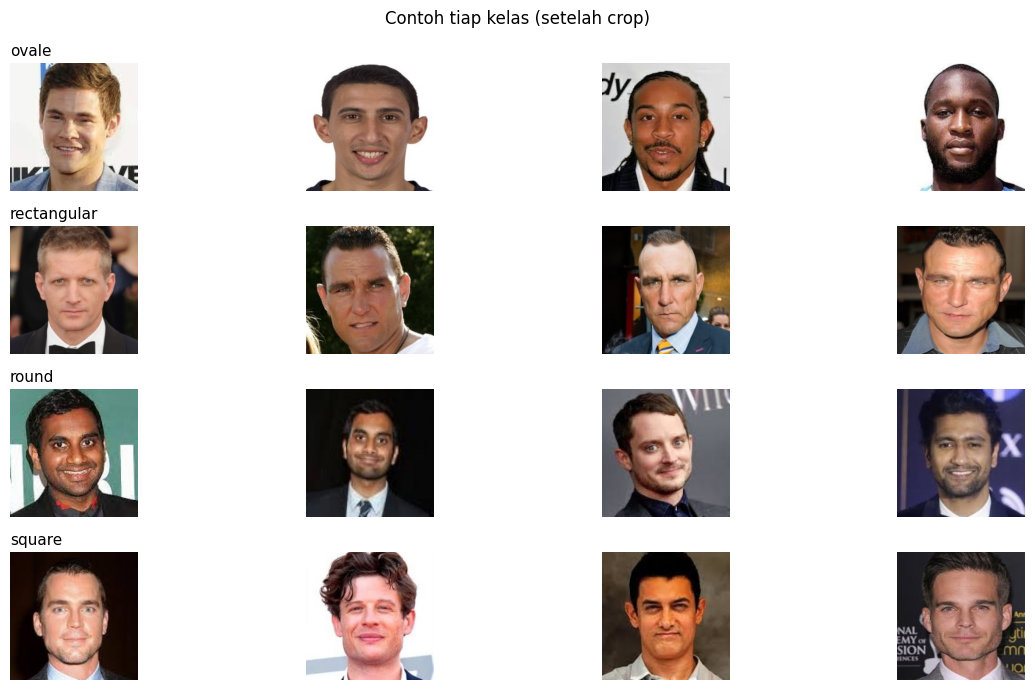

In [ ]:
# ---------- 5. CONTOH GAMBAR ----------
plt.figure(figsize=(13, 7))
rng = np.random.RandomState(SEED)
for i, c in enumerate(CLASSES):
    idxs = rng.choice(np.where(labels == i)[0], 4, replace=False)
    for j, k in enumerate(idxs):
        plt.subplot(4, 4, i*4 + j + 1)
        plt.imshow(X[k]); plt.axis("off")
        if j == 0:
            plt.title(c, fontsize=11, loc="left")
plt.suptitle("Contoh tiap kelas (setelah crop)")
plt.tight_layout(); plt.show()

In [ ]:
# ---------- 6. BUILDER MODEL & CALLBACK ----------
LOSS = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)

def build_head():
    """Kepala klasifikasi, dilatih di atas embedding beku (tahap 1)."""
    i = keras.Input(shape=(EMB_DIM,))
    x = layers.Dropout(0.25)(i)
    x = layers.Dense(128, activation="relu", name="d1")(x)
    x = layers.Dropout(0.15)(x)
    o = layers.Dense(NUM_CLASSES, activation="softmax", name="d2")(x)
    return keras.Model(i, o, name="head")

def build_full():
    """Model utuh untuk tahap 2. Nama layer d1/d2 sengaja disamakan
       dengan kepala supaya bobot tahap 1 bisa dipindahkan."""
    base = keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                          include_top=False, weights="imagenet")
    base.trainable = False
    aug = keras.Sequential([
        layers.RandomFlip("horizontal"),      # wajah cermin masih valid
        layers.RandomRotation(0.06),          # kepala sedikit miring
        layers.RandomZoom(0.06),
    ], name="augment")                        # TANPA flip vertikal
    i = keras.Input(shape=IMG_SHAPE)
    x = layers.Rescaling(1.0)(i)
    x = aug(x)
    x = keras.applications.mobilenet_v2.preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(128, activation="relu", name="d1")(x)
    x = layers.Dropout(0.15)(x)
    o = layers.Dense(NUM_CLASSES, activation="softmax", name="d2")(x)
    return keras.Model(i, o, name="faceshape"), base

def make_callbacks(path, patience):
    """WAJIB objek baru tiap fit(): ModelCheckpoint tidak me-reset nilai
       'best'-nya, jadi objek yang dipakai ulang tidak akan pernah menyimpan
       checkpoint pada training kedua."""
    return [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                                          patience=3, min_lr=1e-7, verbose=0),
        keras.callbacks.ModelCheckpoint(path, monitor="val_accuracy",
                                        save_best_only=True, verbose=0),
    ]

build_full()[0].summary()

Model: "faceshape"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment (Sequential)            │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d1 (Dense)                      │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ d2 (Dense)                      │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ---------- 7. TRAINING: 5-FOLD CV DENGAN OOF ----------
# Setiap gambar diprediksi tepat sekali oleh model yang tidak pernah
# melihatnya -> estimasi dari SELURUH dataset, bukan satu potongan.
#
# PENTING: validation diambil dari porsi TRAINING (85/15), bukan dari
# test fold. Memakai test fold sebagai validation membuat early stopping
# memilih epoch terbaik berdasarkan data ujian -> inflasi 2-4 poin.
oof_prob   = np.zeros((len(paths), NUM_CLASSES), dtype=np.float32)
fold_acc, fold_models, histories = [], [], []
t_start = time.time()

for k, (trv_idx, te_idx) in enumerate(
        StratifiedKFold(N_FOLDS, shuffle=True,
                        random_state=SEED).split(paths, labels), start=1):
    t_fold = time.time()
    tf.keras.utils.set_random_seed(SEED + k)

    tr_idx, va_idx = train_test_split(
        trv_idx, test_size=VAL_FRAC,
        stratify=labels[trv_idx], random_state=SEED)

    # --- tahap 1: kepala di atas embedding (pemanasan, sangat cepat) ---
    # gambar asli + versi flip -> data tahap 1 dua kali lipat, gratis
    t1 = time.time()
    head = build_head()
    head.compile(optimizer=keras.optimizers.Adam(1e-3), loss=LOSS,
                 metrics=["accuracy"])
    h1 = head.fit(np.concatenate([E[tr_idx], E_flip[tr_idx]]),
                  np.concatenate([Y[tr_idx], Y[tr_idx]]),
                  validation_data=(E[va_idx], Y[va_idx]),
                  epochs=EPOCHS_HEAD, batch_size=BATCH_SIZE,
                  callbacks=make_callbacks(
                      f"{WORK_DIR}/f{k}_head.keras", PATIENCE_HEAD),
                  verbose=0)
    t_head = time.time() - t1

    # --- tahap 2: fine-tuning 60 layer teratas ---
    model, base = build_full()
    model.get_layer("d1").set_weights(head.get_layer("d1").get_weights())
    model.get_layer("d2").set_weights(head.get_layer("d2").get_weights())
    base.trainable = True
    for l in base.layers[:len(base.layers)-FINE_TUNE_LAYERS]:
        l.trainable = False
    for l in base.layers:                    # BatchNorm tetap beku
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
    model.compile(optimizer=keras.optimizers.Adam(1e-5),   # LR 100x lebih kecil
                  loss=LOSS, metrics=["accuracy"])
    h2 = model.fit(X[tr_idx], Y[tr_idx], validation_data=(X[va_idx], Y[va_idx]),
                   epochs=EPOCHS_FT, batch_size=BATCH_SIZE,
                   callbacks=make_callbacks(
                       f"{WORK_DIR}/f{k}_ft.keras", PATIENCE_FT),
                   verbose=0)

    # pakai tahap yang val_accuracy-nya lebih tinggi
    if max(h2.history["val_accuracy"]) >= max(h1.history["val_accuracy"]):
        model.load_weights(f"{WORK_DIR}/f{k}_ft.keras"); used = "fine-tune"
    else:
        head.load_weights(f"{WORK_DIR}/f{k}_head.keras")
        model.get_layer("d1").set_weights(head.get_layer("d1").get_weights())
        model.get_layer("d2").set_weights(head.get_layer("d2").get_weights())
        used = "kepala"

    prob = model.predict(X[te_idx], batch_size=BATCH_SIZE, verbose=0)
    oof_prob[te_idx] = prob
    acc = (np.argmax(prob, 1) == labels[te_idx]).mean()

    out = os.path.join(OUT_DIR, f"faceshape_fold{k}.keras")
    model.save(out)
    fold_acc.append(acc); fold_models.append(out)
    histories.append(({a: b for a, b in h1.history.items()},
                      {a: b for a, b in h2.history.items()}))

    # bersihkan memori: model ke disk, bukan ditahan di list
    del model, base, head, h1, h2, prob
    keras.backend.clear_session(); gc.collect()

    print(f"fold {k}/{N_FOLDS}: acc={acc*100:.2f}% ({used:<9}) | "
          f"train={len(tr_idx)} val={len(va_idx)} test={len(te_idx)} | "
          f"kepala {t_head:.0f}s + ft {time.time()-t_fold-t_head:.0f}s | "
          f"RSS {mem_mb():.0f} MB")

fold_acc = np.array(fold_acc)
oof_pred = np.argmax(oof_prob, axis=1)
OOF_ACC  = (oof_pred == labels).mean()
TOP2 = float(np.mean([labels[i] in np.argsort(oof_prob[i])[-2:]
                      for i in range(len(labels))]))

print(f"\nTotal waktu : {(time.time()-t_start)/60:.1f} menit")
print(f"Per fold    : {fold_acc.mean()*100:.2f}% +/- {fold_acc.std()*100:.2f}")
print(f"OOF         : {OOF_ACC*100:.2f}%  (n={len(labels)})")
print(f"Top-2       : {TOP2*100:.2f}%   | tebak acak: 25.00%")

fold 1/5: acc=60.96% (fine-tune) | train=774 val=137 test=228 | kepala 5s + ft 71s | RSS 2577 MB
fold 2/5: acc=63.60% (fine-tune) | train=774 val=137 test=228 | kepala 6s + ft 54s | RSS 2920 MB
fold 3/5: acc=60.53% (kepala   ) | train=774 val=137 test=228 | kepala 10s + ft 49s | RSS 2848 MB
fold 4/5: acc=60.53% (fine-tune) | train=774 val=137 test=228 | kepala 6s + ft 49s | RSS 3194 MB
fold 5/5: acc=59.91% (fine-tune) | train=775 val=137 test=227 | kepala 6s + ft 68s | RSS 3318 MB

Total waktu : 5.4 menit
Per fold    : 61.11% +/- 1.29
OOF         : 61.11%  (n=1139)
Top-2       : 82.88%   | tebak acak: 25.00%


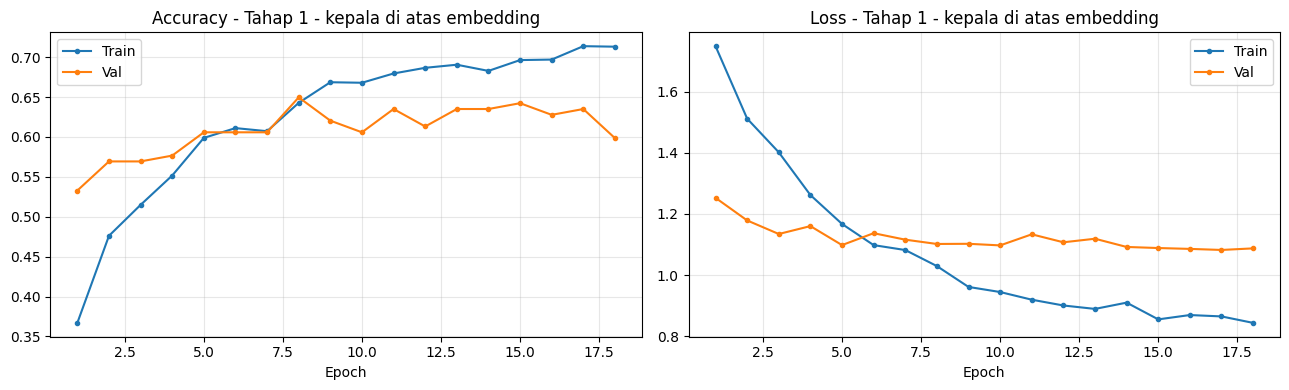

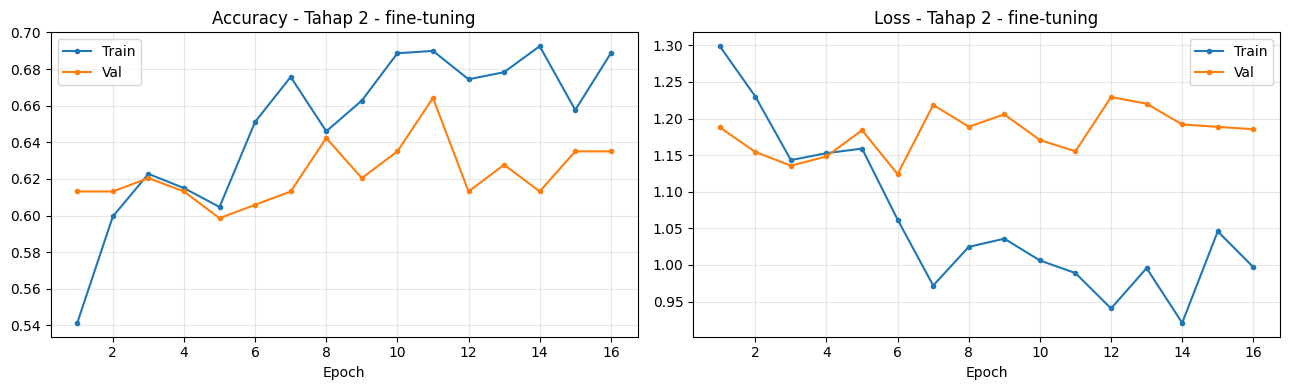

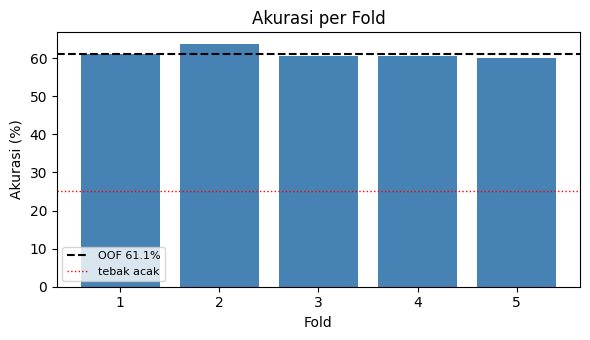

In [ ]:
# ---------- 8. KURVA TRAINING (fold 1) ----------
h1, h2 = histories[0]
for h, name in [(h1, "Tahap 1 - kepala di atas embedding"),
                (h2, "Tahap 2 - fine-tuning")]:
    ep = range(1, len(h["loss"])+1)
    plt.figure(figsize=(13, 4))
    plt.subplot(1, 2, 1)
    plt.plot(ep, h["accuracy"], "o-", ms=3, label="Train")
    plt.plot(ep, h["val_accuracy"], "o-", ms=3, label="Val")
    plt.title(f"Accuracy - {name}"); plt.xlabel("Epoch")
    plt.legend(); plt.grid(alpha=.3)
    plt.subplot(1, 2, 2)
    plt.plot(ep, h["loss"], "o-", ms=3, label="Train")
    plt.plot(ep, h["val_loss"], "o-", ms=3, label="Val")
    plt.title(f"Loss - {name}"); plt.xlabel("Epoch")
    plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 3.5))
plt.bar(range(1, N_FOLDS+1), fold_acc*100, color="steelblue")
plt.axhline(OOF_ACC*100, ls="--", c="black", label=f"OOF {OOF_ACC*100:.1f}%")
plt.axhline(25, ls=":", c="red", lw=1, label="tebak acak")
plt.xlabel("Fold"); plt.ylabel("Akurasi (%)"); plt.title("Akurasi per Fold")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

       ovale     0.6289    0.5111    0.5639       315
 rectangular     0.6000    0.7102    0.6505       245
       round     0.8216    0.5033    0.6242       302
      square     0.5123    0.7545    0.6102       277

    accuracy                         0.6111      1139
   macro avg     0.6407    0.6198    0.6122      1139
weighted avg     0.6454    0.6111    0.6098      1139



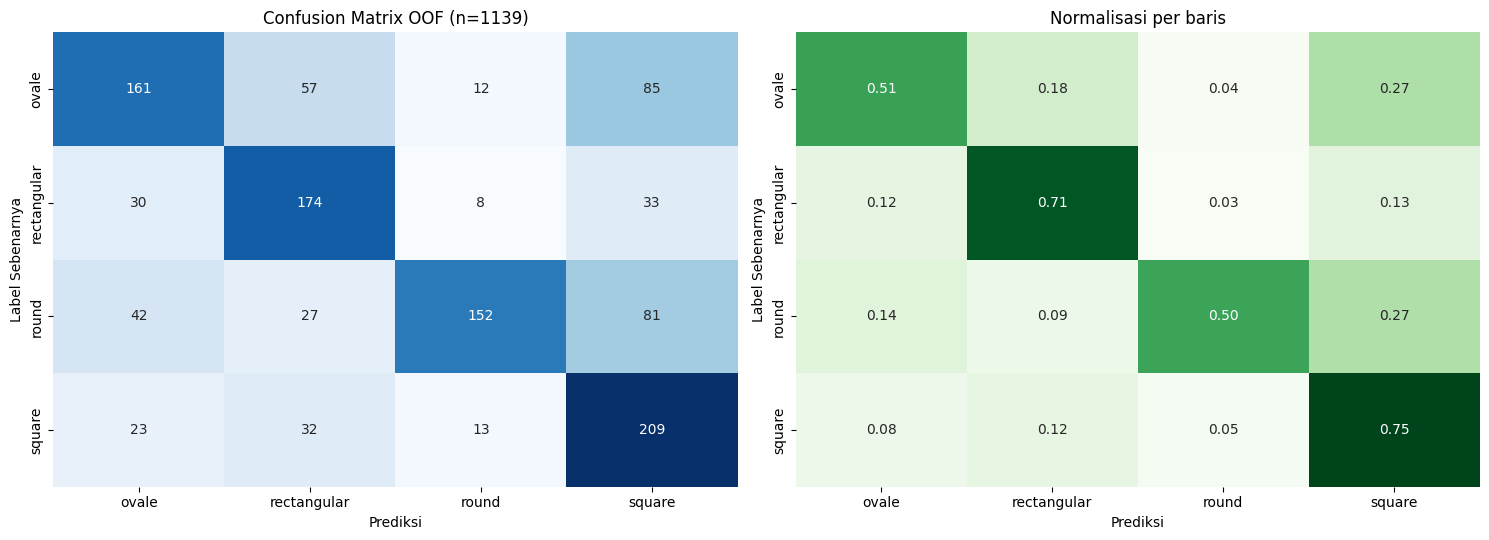

Akurasi per kelas:
  ovale         : 51.11%
  rectangular   : 71.02%
  round         : 50.33%
  square        : 75.45%

Pasangan paling sering tertukar:
  ovale -> square: 85 kali
  round -> square: 81 kali
  ovale -> rectangular: 57 kali
  round -> ovale: 42 kali
  (square/rectangular dan round/ovale memang mirip secara visual)


In [ ]:
# ---------- 9. HASIL: REPORT + CONFUSION MATRIX ----------
print(classification_report(labels, oof_pred, target_names=CLASSES, digits=4))

cm = confusion_matrix(labels, oof_pred)
cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0], cbar=False,
            xticklabels=CLASSES, yticklabels=CLASSES)
ax[0].set_title(f"Confusion Matrix OOF (n={len(labels)})")
ax[0].set_xlabel("Prediksi"); ax[0].set_ylabel("Label Sebenarnya")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Greens", ax=ax[1], cbar=False,
            xticklabels=CLASSES, yticklabels=CLASSES)
ax[1].set_title("Normalisasi per baris")
ax[1].set_xlabel("Prediksi"); ax[1].set_ylabel("Label Sebenarnya")
plt.tight_layout(); plt.show()

print("Akurasi per kelas:")
for i, c in enumerate(CLASSES):
    print(f"  {c:<14}: {cmn[i, i]*100:.2f}%")

print("\nPasangan paling sering tertukar:")
pairs = sorted([(cm[i, j], CLASSES[i], CLASSES[j])
                for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
                if i != j], reverse=True)
for n, a, b in pairs[:4]:
    print(f"  {a} -> {b}: {n} kali")
print("  (square/rectangular dan round/ovale memang mirip secara visual)")

Akurasi menurut asal gambar:
  training_set : 64.54%  (n=801)
  testing_set  : 52.96%  (n=338)
  selisih +11.59 poin | z = 3.62
  (v6 +10.68 z=3.40 | v9 +11.75 z=3.73 | v10 +11.53 z=3.67)

Salah total: 443 | dengan keyakinan >90%: 57

10 kandidat label keliru teratas:
  [ 99.9%] ovale        -> rectangular  TR__ovale__532.jpg
  [ 99.7%] square       -> rectangular  TR__rectangular__image square 158.jpg
  [ 99.3%] round        -> ovale        TR__round__round 636.jpg
  [ 98.9%] ovale        -> rectangular  TR__ovale__528.jpg
  [ 98.9%] square       -> rectangular  TE__square__square t66.jpg
  [ 98.8%] round        -> ovale        TE__round__round t23.jpg
  [ 98.6%] round        -> square       TE__round__round t16.jpg
  [ 98.4%] square       -> ovale        TE__square__square t34.jpg
  [ 98.3%] square       -> rectangular  TR__square__CAR1.jpg
  [ 97.9%] ovale        -> square       TR__rectangular__image ovale 239.jpg

Diekspor: artifacts/suspected_mislabels.csv


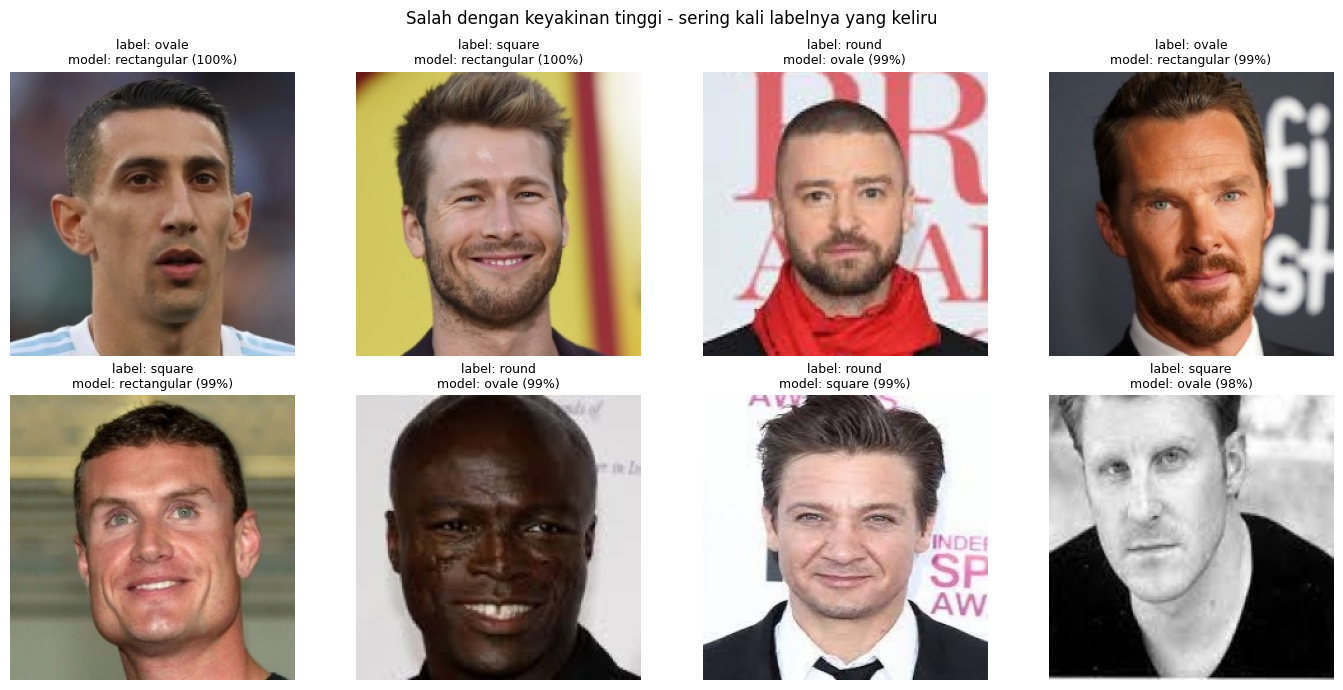

In [ ]:
# ---------- 10. DIAGNOSTIK DATASET ----------
# Temuan yang tereplikasi di v6, v9, v10, v12: gambar asal testing_set
# konsisten lebih sulit. Dicek ulang di sini.
a_tr = (oof_pred[origin == "TR"] == labels[origin == "TR"]).mean()
a_te = (oof_pred[origin == "TE"] == labels[origin == "TE"]).mean()
n1, n2 = (origin == "TR").sum(), (origin == "TE").sum()
se = np.sqrt(a_tr*(1-a_tr)/n1 + a_te*(1-a_te)/n2)
print(f"Akurasi menurut asal gambar:")
print(f"  training_set : {a_tr*100:.2f}%  (n={n1})")
print(f"  testing_set  : {a_te*100:.2f}%  (n={n2})")
print(f"  selisih {(a_tr-a_te)*100:+.2f} poin | z = {(a_tr-a_te)/se:.2f}")
print("  (v6 +10.68 z=3.40 | v9 +11.75 z=3.73 | v10 +11.53 z=3.67)")

# gambar yang salah dengan keyakinan tinggi = kandidat label keliru
conf_wrong = sorted([(oof_prob[i][oof_pred[i]], i) for i in range(len(labels))
                     if oof_pred[i] != labels[i]], reverse=True)
print(f"\nSalah total: {len(conf_wrong)} | dengan keyakinan >90%: "
      f"{sum(1 for c, _ in conf_wrong if c > 0.9)}")
print("\n10 kandidat label keliru teratas:")
for c, i in conf_wrong[:10]:
    print(f"  [{c*100:5.1f}%] {CLASSES[labels[i]]:<12} -> "
          f"{CLASSES[oof_pred[i]]:<12} {os.path.basename(paths[i])[:48]}")

with open(os.path.join(OUT_DIR, "suspected_mislabels.csv"), "w",
          newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["file", "label", "prediksi", "keyakinan", "asal"])
    for c, i in conf_wrong:
        if c < 0.7:
            break
        w.writerow([os.path.basename(paths[i]), CLASSES[labels[i]],
                    CLASSES[oof_pred[i]], f"{c:.4f}", origin[i]])
print(f"\nDiekspor: {OUT_DIR}/suspected_mislabels.csv")

plt.figure(figsize=(14, 7))
for j, (c, i) in enumerate(conf_wrong[:8]):
    plt.subplot(2, 4, j+1)
    plt.imshow(X[i]); plt.axis("off")
    plt.title(f"label: {CLASSES[labels[i]]}\nmodel: {CLASSES[oof_pred[i]]} "
              f"({c*100:.0f}%)", fontsize=9)
plt.suptitle("Salah dengan keyakinan tinggi - sering kali labelnya yang keliru")
plt.tight_layout(); plt.show()

In [ ]:
# ---------- 11. SIMPAN ARTEFAK UNTUK INFERENCE ----------
# model_config.json membuat notebook inference memakai parameter
# pra-pemrosesan yang PERSIS SAMA. Tanpa ini, crop margin atau urutan
# kelas gampang melenceng tanpa disadari.
config = {
    "dibuat": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "classes": CLASSES,
    "img_size": list(IMG_SIZE),
    "crop_margin": CROP_MARGIN,
    "cascade": "haarcascade_frontalface_default.xml",
    "input_dtype": "uint8",
    "catatan_input": "model menerima uint8 mentah; normalisasi ada di dalam model",
    "arsitektur": "MobileNetV2 + GAP + Dropout + Dense128 + Dense4",
    "fine_tune_layers": FINE_TUNE_LAYERS,
    "label_smoothing": LABEL_SMOOTHING,
    "n_folds": N_FOLDS,
    "seed": SEED,
    "n_gambar": int(len(labels)),
    "oof_accuracy": float(OOF_ACC),
    "top2_accuracy": float(TOP2),
    "fold_accuracy": [float(a) for a in fold_acc],
    "akurasi_per_kelas": {CLASSES[i]: float(cmn[i, i])
                          for i in range(NUM_CLASSES)},
    "models": [os.path.basename(m) for m in fold_models],
}
with open(os.path.join(OUT_DIR, "model_config.json"), "w") as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
with open(os.path.join(OUT_DIR, "class_names.txt"), "w") as f:
    f.write("\n".join(CLASSES))
np.savez(os.path.join(OUT_DIR, "oof_results.npz"),
         files=np.array([os.path.basename(p) for p in paths]),
         labels=labels, origin=origin, oof_prob=oof_prob, fold_acc=fold_acc)

print(f"Tersimpan di {OUT_DIR}/")
for f_ in sorted(os.listdir(OUT_DIR)):
    print("  ", f_)
print(f"\nFolder '{WORK_DIR}/' berisi hasil antara dan aman dihapus.")

Tersimpan di artifacts/
   class_names.txt
   faceshape_fold1.keras
   faceshape_fold2.keras
   faceshape_fold3.keras
   faceshape_fold4.keras
   faceshape_fold5.keras
   model_config.json
   oof_results.npz
   suspected_mislabels.csv

Folder 'build/' berisi hasil antara dan aman dihapus.


In [ ]:
# ---------- 12. RINGKASAN ----------
print("=" * 62)
print("HASIL AKHIR")
print("=" * 62)
print(f"\nDataset  : {len(pool_paths)} gambar mentah -> {len(labels)} setelah dedupe")
print(f"           {n_relabel} label diperbaiki | "
      f"{is_dup.sum()} kembar dibuang | crop {n_found/len(pool_paths)*100:.1f}%")
print(f"\nAkurasi  : {OOF_ACC*100:.2f}% (OOF {N_FOLDS}-fold, seluruh {len(labels)} gambar)")
print(f"           per fold {fold_acc.mean()*100:.2f}% +/- {fold_acc.std()*100:.2f}")
print(f"Top-2    : {TOP2*100:.2f}%")
print(f"Acak     : 25.00% | tebak mayoritas: "
      f"{Counter(labels).most_common(1)[0][1]/len(labels)*100:.2f}%")
print(f"\nModel    : ensemble {N_FOLDS} fold di {OUT_DIR}/")
print("\nLangkah berikutnya: jalankan 15_inference.ipynb untuk memakai model.")
print("\nCATATAN untuk laporan: angka ini memakai protokol gabung-lalu-split-ulang.")
print("Split folder bawaan dataset menghasilkan angka jauh lebih rendah (~43%)")
print("karena gambar testing_set konsisten lebih sulit. Sajikan keduanya.")

HASIL AKHIR

Dataset  : 1312 gambar mentah -> 1139 setelah dedupe
           59 label diperbaiki | 173 kembar dibuang | crop 98.9%

Akurasi  : 61.11% (OOF 5-fold, seluruh 1139 gambar)
           per fold 61.11% +/- 1.29
Top-2    : 82.88%
Acak     : 25.00% | tebak mayoritas: 27.66%

Model    : ensemble 5 fold di artifacts/

Langkah berikutnya: jalankan 15_inference.ipynb untuk memakai model.

CATATAN untuk laporan: angka ini memakai protokol gabung-lalu-split-ulang.
Split folder bawaan dataset menghasilkan angka jauh lebih rendah (~43%)
karena gambar testing_set konsisten lebih sulit. Sajikan keduanya.
